In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
import pandas as pd

df = pd.read_csv("Unemployment in India.csv")
print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [3]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (768, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [4]:
df.columns = df.columns.str.strip()

print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [5]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


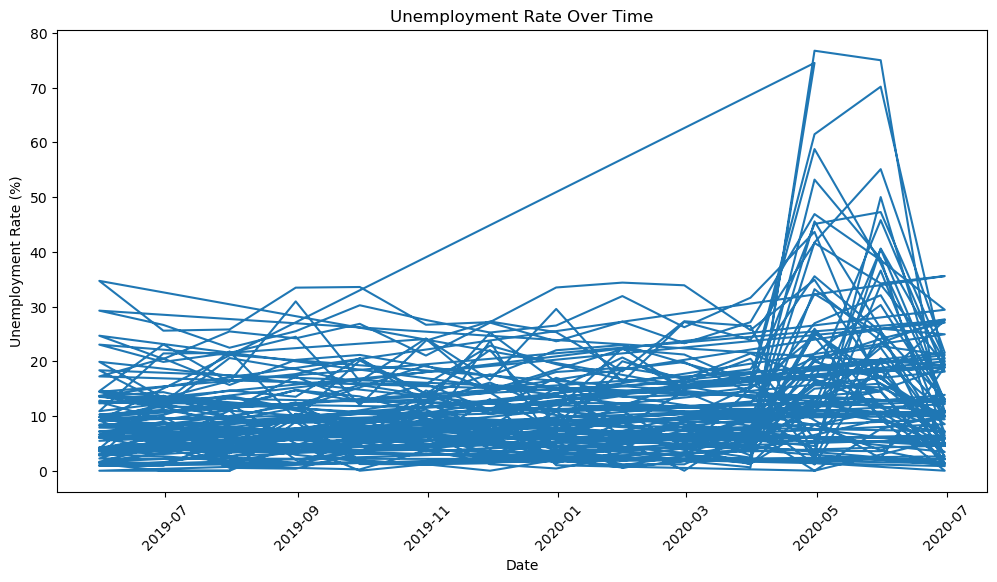

In [7]:
plt.figure(figsize=(12,6))

plt.plot(
    df['Date'],
    df['Estimated Unemployment Rate (%)']
)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

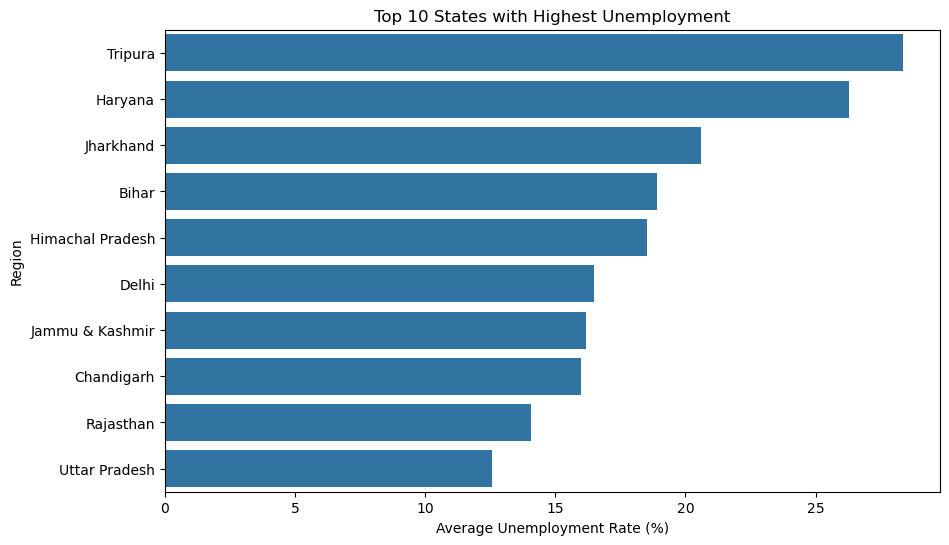

In [8]:
top_states = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States with Highest Unemployment")
plt.xlabel("Average Unemployment Rate (%)")

plt.show()

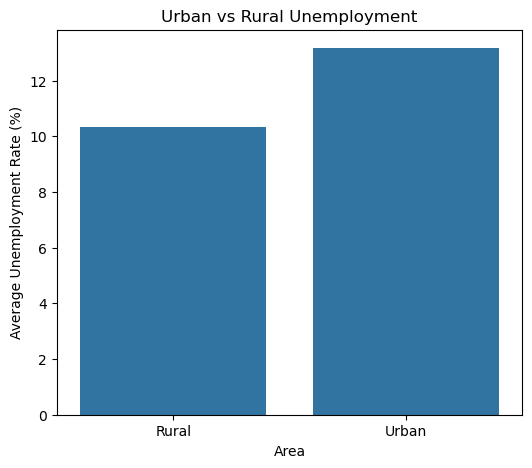

In [9]:
area_data = df.groupby('Area')[
    'Estimated Unemployment Rate (%)'
].mean()

plt.figure(figsize=(6,5))

sns.barplot(
    x=area_data.index,
    y=area_data.values
)

plt.title("Urban vs Rural Unemployment")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

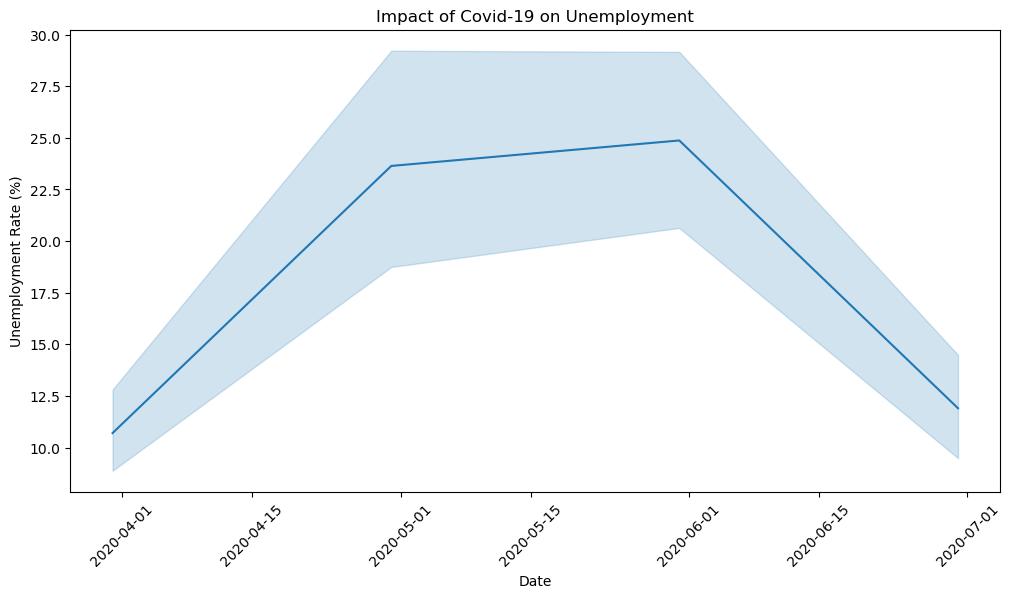

In [10]:
covid_data = df[df['Date'] >= '2020-03-01']

plt.figure(figsize=(12,6))

sns.lineplot(
    data=covid_data,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Impact of Covid-19 on Unemployment")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

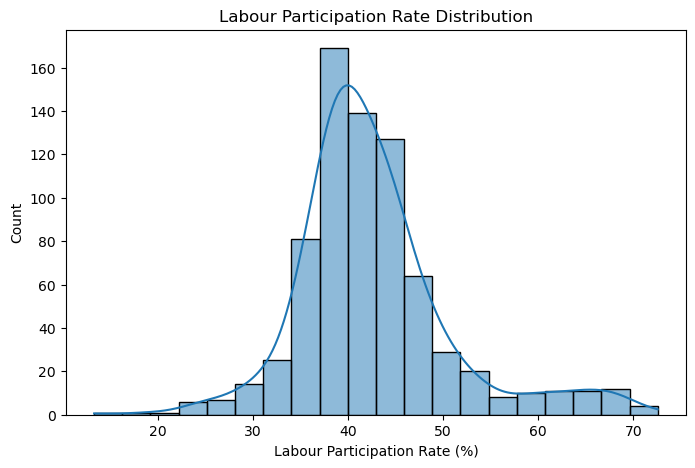

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated Labour Participation Rate (%)'],
    bins=20,
    kde=True
)

plt.title("Labour Participation Rate Distribution")
plt.xlabel("Labour Participation Rate (%)")

plt.show()

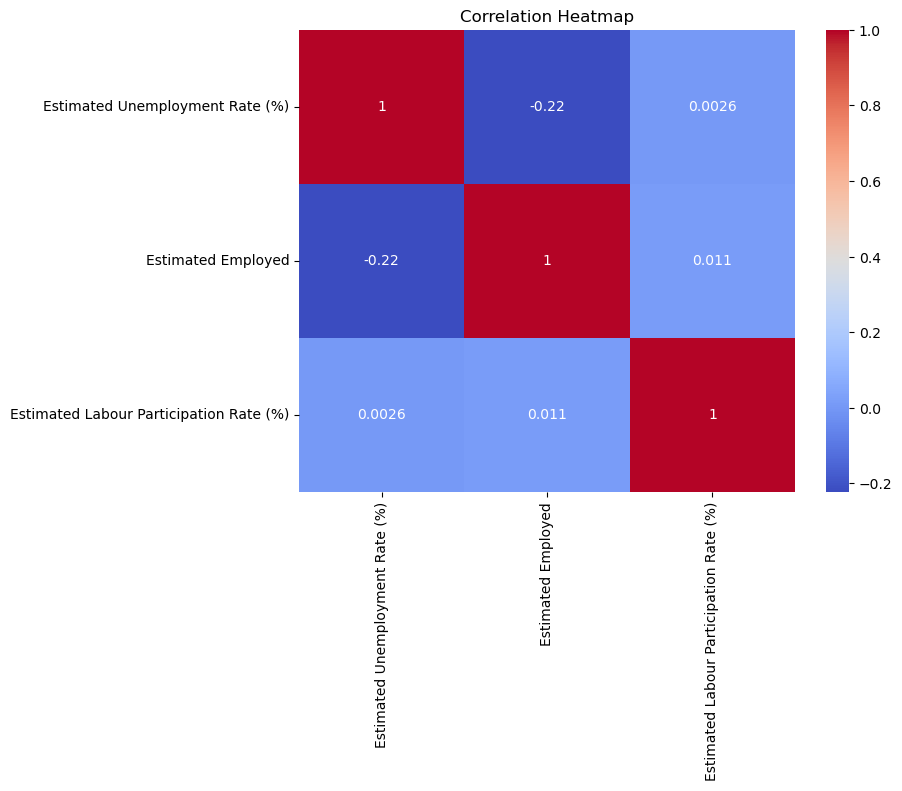

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Unemployment Analysis in India using Python

## CodeAlpha Data Science Internship - Task 2

### Objective
To analyze unemployment trends in India, study the impact of Covid-19, and generate insights using Python data analysis and visualization techniques.